In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

print("Everything is working!")

Everything is working!


In [2]:
# ── CELL 1: Import Libraries ──────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
# ── CELL 2: Load YOUR CSV File ────────────────────────
df = pd.read_csv('HousingData.csv')

print('✅ Dataset loaded!')
print(f'Shape: {df.shape}  ← (rows, columns)')
print(f'Columns: {list(df.columns)}')
df.head()

✅ Dataset loaded!
Shape: (506, 14)  ← (rows, columns)
Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [9]:
# ── CELL 3: Check Missing Values ──────────────────────
print('=== MISSING VALUES PER COLUMN ===')
missing = df.isnull().sum()
print(missing[missing > 0])  # only show columns that have missing
print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print('\n=== STATISTICS ===')
print(df.describe().round(2))

=== MISSING VALUES PER COLUMN ===
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64

Total missing values: 120

=== STATISTICS ===
         CRIM      ZN   INDUS    CHAS     NOX      RM     AGE     DIS     RAD  \
count  486.00  486.00  486.00  486.00  506.00  506.00  486.00  506.00  506.00   
mean     3.61   11.21   11.08    0.07    0.55    6.28   68.52    3.80    9.55   
std      8.72   23.39    6.84    0.26    0.12    0.70   28.00    2.11    8.71   
min      0.01    0.00    0.46    0.00    0.38    3.56    2.90    1.13    1.00   
25%      0.08    0.00    5.19    0.00    0.45    5.89   45.18    2.10    4.00   
50%      0.25    0.00    9.69    0.00    0.54    6.21   76.80    3.21    5.00   
75%      3.56   12.50   18.10    0.00    0.62    6.62   93.98    5.19   24.00   
max     88.98  100.00   27.74    1.00    0.87    8.78  100.00   12.13   24.00   

          TAX  PTRATIO       B   LSTAT    MEDV  
count  506.00   506.00  506.00  486.00  506.00  
mean  

In [10]:
# ── CELL 4: Fix Missing Values ────────────────────────
# File has 120 missing values spread across 6 columns
# I fill them with the MEDIAN of each column
# (Median is better than average when data has extreme values)

cols_with_missing = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'AGE', 'LSTAT']

for col in cols_with_missing:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'  {col}: filled {missing[col]} missing values with median = {median_val:.2f}')

print(f'\n✅ Missing values remaining: {df.isnull().sum().sum()}')

  CRIM: filled 20 missing values with median = 0.25
  ZN: filled 20 missing values with median = 0.00
  INDUS: filled 20 missing values with median = 9.69
  CHAS: filled 20 missing values with median = 0.00
  AGE: filled 20 missing values with median = 76.80
  LSTAT: filled 20 missing values with median = 11.43

✅ Missing values remaining: 0


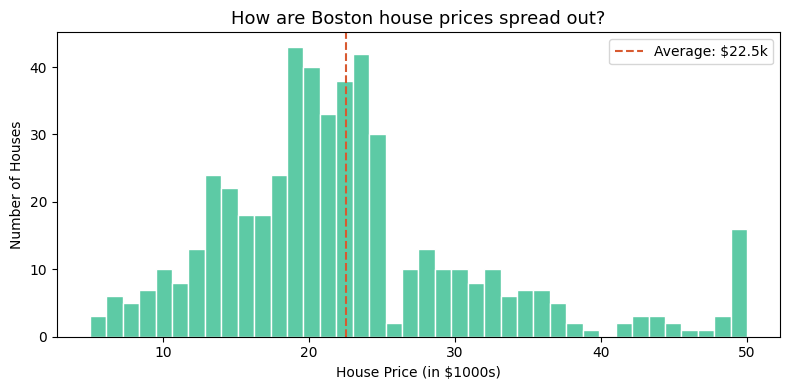

Average price : $22.5k
Cheapest house: $5.0k
Priciest house: $50.0k


In [11]:
# ── CELL 5: Chart 1 — Price Distribution ──────────────
plt.figure(figsize=(8, 4))
plt.hist(df['MEDV'], bins=40, color='#5DCAA5', edgecolor='white')
plt.title('How are Boston house prices spread out?', fontsize=13)
plt.xlabel('House Price (in $1000s)')
plt.ylabel('Number of Houses')
plt.axvline(df['MEDV'].mean(), color='#D85A30', linestyle='--',
            label=f"Average: ${df['MEDV'].mean():.1f}k")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Average price : ${df['MEDV'].mean():.1f}k")
print(f"Cheapest house: ${df['MEDV'].min():.1f}k")
print(f"Priciest house: ${df['MEDV'].max():.1f}k")

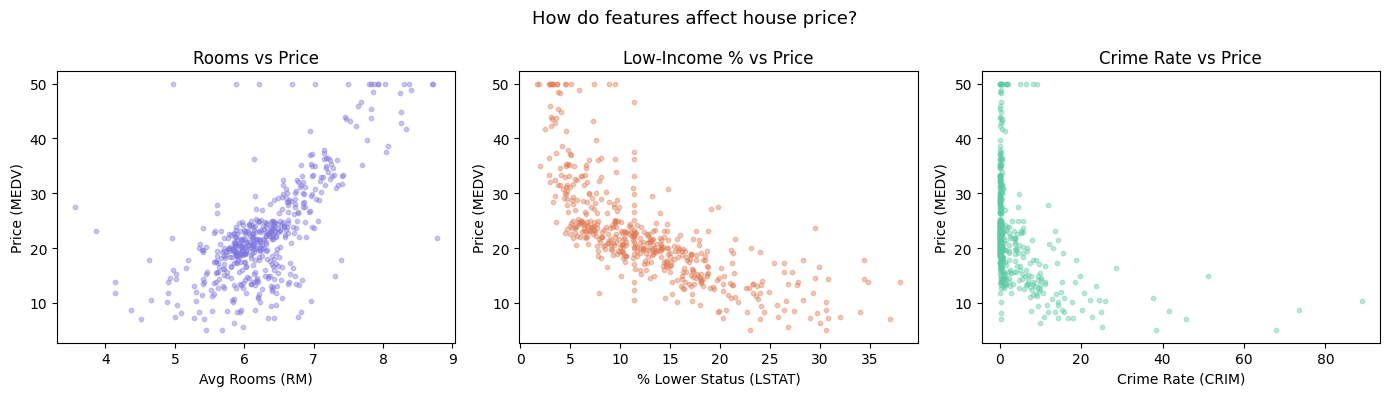

Insight: More rooms = higher price. More crime/poverty = lower price. Makes sense!


In [12]:
# ── CELL 6: Chart 2 — Key Features vs Price ───────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# RM = number of rooms
axes[0].scatter(df['RM'], df['MEDV'], alpha=0.4, color='#7F77DD', s=10)
axes[0].set_title('Rooms vs Price')
axes[0].set_xlabel('Avg Rooms (RM)')
axes[0].set_ylabel('Price (MEDV)')

# LSTAT = % lower income population
axes[1].scatter(df['LSTAT'], df['MEDV'], alpha=0.4, color='#E07B54', s=10)
axes[1].set_title('Low-Income % vs Price')
axes[1].set_xlabel('% Lower Status (LSTAT)')
axes[1].set_ylabel('Price (MEDV)')

# CRIM = crime rate
axes[2].scatter(df['CRIM'], df['MEDV'], alpha=0.4, color='#5DCAA5', s=10)
axes[2].set_title('Crime Rate vs Price')
axes[2].set_xlabel('Crime Rate (CRIM)')
axes[2].set_ylabel('Price (MEDV)')

plt.suptitle('How do features affect house price?', fontsize=13)
plt.tight_layout()
plt.show()
print('Insight: More rooms = higher price. More crime/poverty = lower price. Makes sense!')

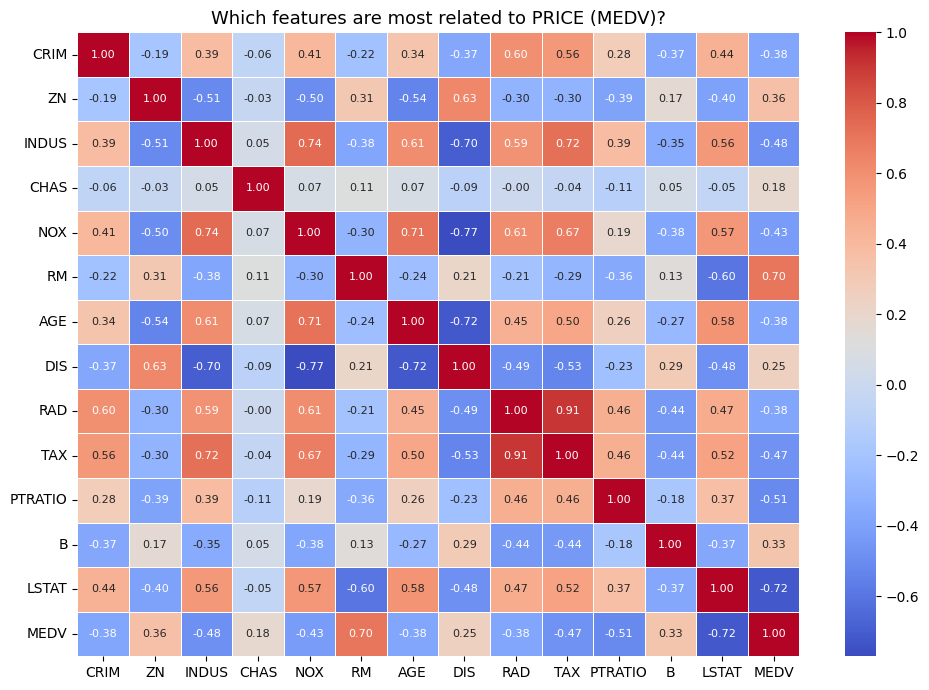

RM has highest POSITIVE correlation with price
LSTAT has highest NEGATIVE correlation with price


In [13]:
# ── CELL 7: Chart 3 — Correlation Heatmap ─────────────
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr().round(2),
            annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Which features are most related to PRICE (MEDV)?', fontsize=13)
plt.tight_layout()
plt.show()
print('RM has highest POSITIVE correlation with price')
print('LSTAT has highest NEGATIVE correlation with price')

In [14]:
# ── CELL 8: Prepare Features & Target ─────────────────
X = df.drop('MEDV', axis=1)   # all columns except price = features
y = df['MEDV']                 # price column = target/answer

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features so all columns are on the same scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training houses : {len(X_train)}')
print(f'Testing  houses : {len(X_test)}')
print('✅ Data ready for training!')

Training houses : 404
Testing  houses : 102
✅ Data ready for training!


In [15]:
# ── CELL 9: Model 1 — Linear Regression ───────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2  = r2_score(y_test, lr_pred)

print('── Linear Regression ──')
print(f'R² Score : {lr_r2:.2f}  (1.0 = perfect)')
print(f'MSE      : {lr_mse:.2f} (lower = better)')

── Linear Regression ──
R² Score : 0.66  (1.0 = perfect)
MSE      : 25.00 (lower = better)


In [16]:
# ── CELL 10: Model 2 — Random Forest ──────────────────
# This is smarter — 100 decision trees vote together!
# Takes ~30 seconds. Normal!
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
rf_pred = rf.predict(X_test_sc)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

print('── Random Forest ──')
print(f'R² Score : {rf_r2:.2f}  ← should be better!')
print(f'MSE      : {rf_mse:.2f}')
print()
print('── Comparison ──')
print(f'Linear Regression R² : {lr_r2:.2f}')
print(f'Random Forest     R² : {rf_r2:.2f}  ← winner!')

── Random Forest ──
R² Score : 0.89  ← should be better!
MSE      : 8.38

── Comparison ──
Linear Regression R² : 0.66
Random Forest     R² : 0.89  ← winner!


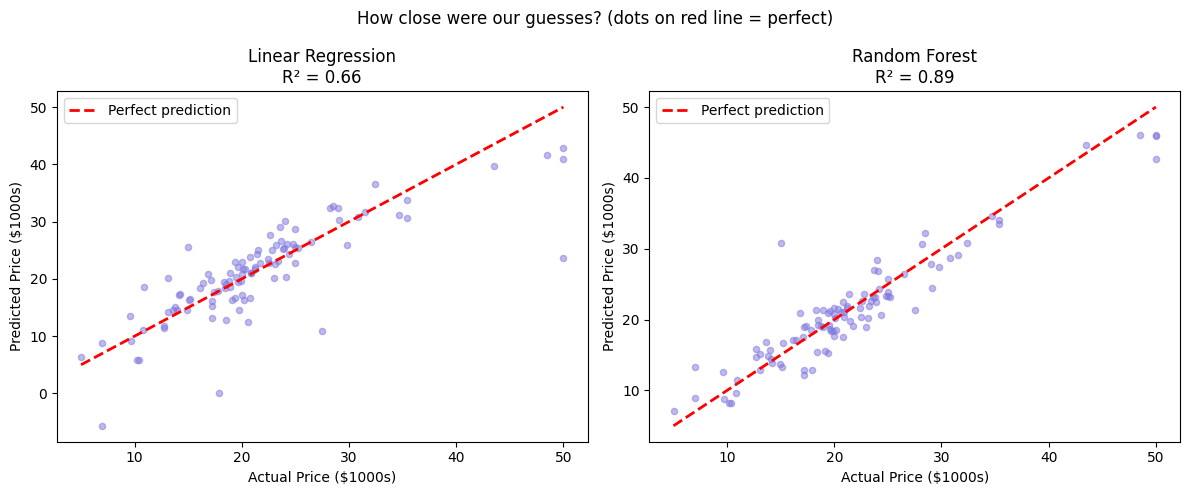

In [17]:
# ── CELL 11: Chart — Actual vs Predicted ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title, r2 in zip(
    axes,
    [lr_pred, rf_pred],
    ['Linear Regression', 'Random Forest'],
    [lr_r2, rf_r2]
):
    ax.scatter(y_test, pred, alpha=0.5, color='#7F77DD', s=20)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual Price ($1000s)')
    ax.set_ylabel('Predicted Price ($1000s)')
    ax.set_title(f'{title}\nR² = {r2:.2f}')
    ax.legend()

plt.suptitle('How close were our guesses? (dots on red line = perfect)', fontsize=12)
plt.tight_layout()
plt.show()

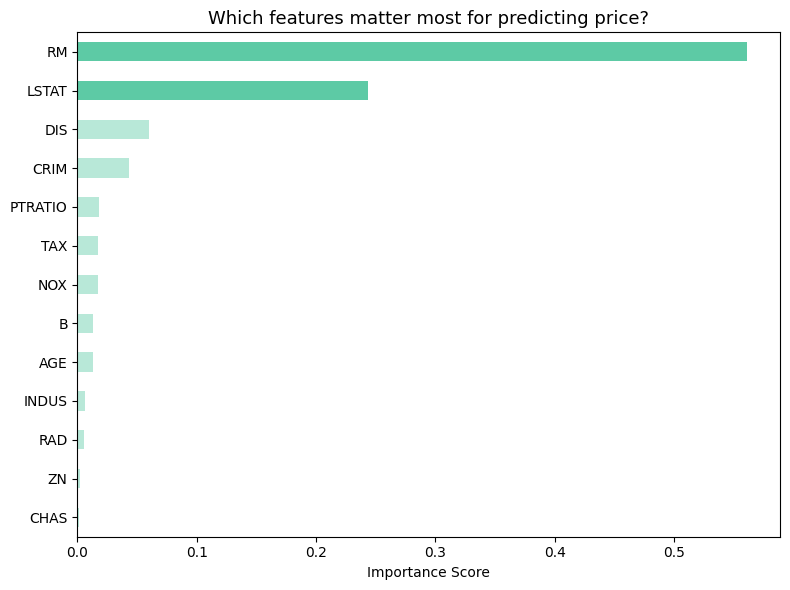

Top 3 most important features:
  1. RM — 0.561
  2. LSTAT — 0.243
  3. DIS — 0.060


In [18]:
# ── CELL 12: Feature Importance ───────────────────────
importances = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = ['#5DCAA5' if v > 0.1 else '#B8E8D8' for v in importances]
importances.plot(kind='barh', color=colors)
plt.title('Which features matter most for predicting price?', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print('Top 3 most important features:')
for i, (feat, val) in enumerate(importances.sort_values(ascending=False).head(3).items(), 1):
    print(f'  {i}. {feat} — {val:.3f}')

In [21]:
# ── CELL 13: Final Summary ────────────────────────────
print('=' * 45)
print('   BOSTON HOUSE PRICE PREDICTION')
print('   ShadowFox AIML Internship — Beginner Task')
print('=' * 45)
print(f'  Dataset       : HousingData.csv ')
print(f'  Total houses  : {len(df)}')
print(f'  Features used : {X.shape[1]}')
print(f'  Missing values: Filled with column median')
print()
print(f'  Model 1 — Linear Regression')
print(f'    R² Score : {lr_r2:.2f}')
print(f'    MSE      : {lr_mse:.2f}')
print()
print(f'  Model 2 — Random Forest')
print(f'    R² Score : {rf_r2:.2f}  ✅ Best Model')
print(f'    MSE      : {rf_mse:.2f}')
print()
top_feat = importances.sort_values(ascending=False).index[0]
print(f'  Top Feature   : {top_feat}')
print(f'  Conclusion    : Random Forest outperforms')
print(f'                  Linear Regression on this dataset')
print('=' * 45)

   BOSTON HOUSE PRICE PREDICTION
   ShadowFox AIML Internship — Beginner Task
  Dataset       : HousingData.csv 
  Total houses  : 506
  Features used : 13
  Missing values: Filled with column median

  Model 1 — Linear Regression
    R² Score : 0.66
    MSE      : 25.00

  Model 2 — Random Forest
    R² Score : 0.89  ✅ Best Model
    MSE      : 8.38

  Top Feature   : RM
  Conclusion    : Random Forest outperforms
                  Linear Regression on this dataset
